# Использование инструментов в Yandex AI Studio

В этой лекции мы рассмотрим использование агентами различных инструментов: файлового поиска, поиска в интернет, интерпретатора кода и внешних инструментов MCP.

Установим необходимые библиотеки:

In [ ]:
%pip install --upgrade openai python-dotenv Pillow shwarsutils

**ВНИМАНИЕ**: После установки библиотек рекомендуется перезапустить Kernel ноутбука.

## Авторизация

Для авторизации в облаке используются специальные значения:

* `folder_id` - это идентификатор облачного каталога
* `api_key` - ключ для доступа к сервисам, который можно сгенерировать в веб-консоли AI Studio

Если вы используете Google Colab - поместите `folder_id` и `api_key` в секреты Google Colab, и запустите ячейку ниже:

In [ ]:
from google.colab import userdata

folder_id = userdata.get('folder_id')
api_key = userdata.get('api_key')

Если вы используете локальное окружение Jupyter Notebooks или Binder, рекомендуем положить значения `folder_id` и `api_key` в файлик `.env`, рядом с ноутбуком, и выполнить ячейку ниже:

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

folder_id = os.environ["folder_id"]
api_key = os.environ["api_key"]

In [2]:
from openai import OpenAI
import io
import base64
import json
from PIL import Image as PILImage

model_alice = f"gpt://{folder_id}/aliceai-llm"
model_yagpt = f"gpt://{folder_id}/yandexgpt-5.1"
model_qwen = f"gpt://{folder_id}/qwen3.6-35b-a3b/latest"
model_qwen3 = f"gpt://{folder_id}/qwen3-235b-a22b-fp8/latest"
model_deepseek = f"gpt://{folder_id}/deepseek-v32/latest"


client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id
)

In [3]:
from IPython.display import Markdown, display

def printx(string):
    """Вывод текста в формате Markdown."""
    display(Markdown(string))

## Поиск в интернет

Рассмотрим такую задачу: вам хочется быть в курсе всех новостей, которые происходят в мире агентных систем, и поэтому вы хотите получать каждый понедельник сводку этих новостей.

Естественно, языковая модель не может знать последние новости, и для получениях таких новостей ей нужен какой-то **инструмент**. Можно попробовать использовать встроенный инструмент веб-поиска.

In [4]:
from datetime import datetime

instr = f"""
Ты - новостной редактор, в задачи которого входит просмотреть все последние новости за прошедшую неделю в интернет на указанную тему и собрать по ним тематический дайджест. Текущая дата - {datetime.now()}
"""

web_search = {
    "type" : "web_search",
    "search_context_size" : "medium"
}

res = client.responses.create(
    model=model_deepseek,
    instructions = instr,
    tools = [web_search],
    input=f"ИИ-агенты"
)

printx(res.output_text)



# 🤖 Дайджест новостей: ИИ-агенты (11–18 июня 2026)

---

## 🏦 Сбер запустил платформу GigaNetwork для «агентной экономики»

**18 июня** — Первый зампред правления Сбера Александр Ведяхин в эфире НТВ раскрыл детали платформы **GigaNetwork**, на которой ИИ-агенты автономно заключают сделки между юридическими лицами. Агент покупателя сам анализирует предложения, сверяет условия поставки, цену, качество и референсы, после чего заключает сделку. Банк выступает посредником, фиксируя транзакцию в блокчейне. Ведяхин анонсировал наступление эры **«агентной экономики»**, отметив, что ИИ-агенты — «как личный агент "007"», готовый круглосуточно выполнять поручения.

📎 *Lenta.ru, 18.06.2026*

---

## 🛒 Яндекс запустил ИИ-агента «Найти дешевле»

**16 июня** — Яндекс представил нового ИИ-агента, встроенного в «Алису AI». Достаточно вставить ссылку на товар в чат — и агент за пару минут проанализирует предложения в интернет-магазинах, на маркетплейсах и у локальных продавцов, найдя лучшую цену. По словам руководителя направления еком-агентов Яндекса Натальи Басиной, «уже в скором будущем ИИ-агенты заметно улучшат наш опыт покупки».

📎 *78.ru, 16.06.2026*

---

## 🧠 OpenAI покупает Ona и интегрирует Visa: агенты учатся платить

**11 июня** — OpenAI объявила о приобретении стартапа **Ona** (разработка безопасных облачных сред для автономных агентов) и интеграции **Visa** в ChatGPT. Теперь ИИ-агенты смогут совершать покупки в любой точке, принимающей Visa, — это серьёзный шаг к «агентной коммерции». Аналитики отмечают, что на фоне этих новостей OpenAI готовит крупнейшее обновление ChatGPT, превращая его в «суперапп» с акцентом на агентов и инструменты для кодинга.

📎 *Stocktwits / TNW, 11.06.2026*

---

## 🏢 Microsoft усиливает позиции в агентном ИИ

**Неделя 11–18 июня** — Microsoft анонсировала несколько ключевых обновлений:

- **Copilot Studio** получил расширенные средства оркестровки для создания более сложных ИИ-агентов и автоматизации рабочих процессов.
- **Microsoft Foundry** — новые функции для продвижения агентов от прототипов к продакшену, включая публичное предварительное тестирование `Foundry IQ`.
- **Microsoft Discovery** (платформа для автономных агентов в научных исследованиях) вышла в общую доступность — именно она помогла в создании квантового чипа Majorana 2.
- Агент **Scout** («Скаут») для рабочих задач, построенный на открытом коде, переопределяет подход к персональным ассистентам.

📎 *Dawan Africa, InfoQ, Let's Data Science, Copilot at Work, 08–16.06.2026*

---

## 🏪 Meta запускает Business Agent и изучает премиум-агента Hatch

**10–11 июня** — Meta представила **Business Agent** — ИИ-агента для автоматизации обслуживания клиентов, продаж и бизнес-операций. Одновременно появилась информация, что Meta рассматривает запуск премиум-агента **Hatch** за $200/месяц для персональных задач. Кроме того, Meta внедряет **AI Mode** в поисковую строку Facebook, превращая её в разговорный ИИ-инструмент.

📎 *The Economic Times, WinBuzzer, 10–11.06.2026*

---

## 🎨 Adobe и другие гиганты: CX Enterprise Coworker и корпоративные агенты

**10–11 июня** — Adobe объявила о выходе **CX Enterprise Coworker** — агентного ИИ-решения для автоматизации маркетинга и оркестрации клиентского опыта. **Ramp** запустил Applied AI Solutions для развёртывания ИИ-агентов в финансах предприятий. **Asana** представила **Dash** — ИИ-агента в роли «руководителя штаба» для управления проектами.

📎 *Adobe Newsroom, PRNewswire, 10–11.06.2026*

---

## 🇨🇳 Китайские игроки: Alibaba Qwen3.7-Plus и Moonshot AI с роем агентов

- **Alibaba** представила **Qwen3.7-Plus** — агента для автоматизации задач на экране компьютера: кодинг, работа в облачных консолях и приложениях — выход за пределы браузера.
- **Moonshot AI** анонсировала десктоп-агента **Kimi Work** с архитектурой «роя» — до **300 параллельных агентов**, интеграцией с браузером и постоянной памятью.

📎 *WinBuzzer, 06–08.06.2026*

---

## 🛡️ Безопасность и регуляторика: рейды, иски и Zero Trust

- **Amazon подал иск** против агента **Perplexity Comet** по Computer Fraud and Abuse Act (CFAA) — из-за способности агента совершать покупки на Amazon. ACLU предупреждает, что решение в пользу Amazon создаст опасный прецедент для браузерных расширений.
- **Google DeepMind** объявила о грантовой программе до $10 млн на исследования безопасности **мультиагентных систем**.
- Исследователи нашли уязвимости в **LangGraph**, подчёркивая необходимость безопасности памяти ИИ-агентов.
- Принципы **Zero Trust** для ИИ-агентов предлагается внедрять на уровне аппаратного обеспечения.
- Эксперты отмечают: **97% команд разработки** уже используют ИИ-агентов для кодинга, но полное управление внедрено лишь у 30%.

📎 *Infosecurity Magazine, Utimaco, AI Agents Directory, 08–11.06.2026*

---

## 💸 Финансирование и рынок

- **PhoenixAI** привлекла $80 млн (Series B) на «Agentic AI Database».
- **Cyera** закрыла раунд на $600 млн при оценке $12 млрд — защита данных для ИИ.
- **Perplexity** собрала $200 млн для своего браузера Comet.
- **Jedify** — $24 млн на корпоративных ИИ-агентов.
- McKinsey прогнозирует: Gen AI может автоматизировать **60–70% рутинных задач**; Gartner ожидает, что к концу 2026 года **80% предприятий** будут использовать ИИ-агентов.

📎 *AI Agents Directory, ЦСИО на РБК, Stocktwits, 11–16.06.2026*

---

## 🔮 Тренды недели: кратко

| Тренд | Суть |
|-------|------|
| **Агентная экономика** | ИИ-агенты самостоятельно заключают сделки (Сбер GigaNetwork) и совершают платежи (OpenAI + Visa) |
| **Рой агентов** | Переход от одиночных агентов к мультиагентным системам (Kimi Work — 300 агентов) |
| **ИИ-агент как «суперапп»** | ChatGPT, Copilot Studio и Facebook AI Mode превращаются в агентные платформы |
| **Безопасность становится приоритетом** | Иски, Zero Trust, гранты на мультиагентную безопасность |
| **97% разработчиков уже с ИИ** | Рынок труда трансформируется: рутина автоматизируется, нужны «архитекторы» и «режиссёры» |

---

*Дайджест подготовлен 18 июня 2026 года на основе публикаций Lenta.ru, 78.ru, РБК, TNW, AI Agents Directory, LinkedIn AI Insiders и других источников.*

В ответе модели (`res`) содержится информация о том, какие инструменты были вызваны. 
Рассмотрим, как получить детали вызова инструмента поиска в интернет:

In [ ]:
def inspect_result(res):
    print("=== СТРУКТУРА ОТВЕТА (res) ===")
    print(f"ID ответа: {res.id}")
    print(f"Модель: {res.model}")
    print(f"Количество output-элементов: {len(res.output)}")
    print()

    print("=== ДЕТАЛИ КАЖДОГО OUTPUT-ЭЛЕМЕНТА ===")
    for i, item in enumerate(res.output):
        if item.type == "web_search_call":
            print(f"Поиск: {item.action.query}")
        elif item.type == "message":
            for content_item in item.content:
                if content_item.type == "output_text":
                    for ann in content_item.annotations:
                        print(f"Источник: {ann.url}")
                        print(f"Заголовок: {ann.title}")
                    if len(content_item.text)>2:
                        print(f"Текст: {content_item.text[:20].replace('\n','')}...")

inspect_result(res)

=== СТРУКТУРА ОТВЕТА (res) ===
ID ответа: c01b95c5-77d2-4c92-9e7e-4904ea55a6b9
Модель: gpt://b1gg3vl8onffhjb2nuct/deepseek-v32/latest
Количество output-элементов: 6

=== ДЕТАЛИ КАЖДОГО OUTPUT-ЭЛЕМЕНТА ===
Поиск: {"query":"ИИ-агенты новости последние неделя 2026","lang":"ru"}
Поиск: {"query":"AI agents news June 2026 latest","lang":"en"}
Источник: https://aiagentsdirectory.com/news
Заголовок: AI Agents News | Daily Briefs and 7-Day Summary
Источник: https://www.linkedin.com/pulse/ai-news-highlights-from-16th-june-2026-ai-insiders-news-igkkf
Заголовок: AI News Highlights from 16th of June, 2026
Источник: https://aiagentstore.ai/ai-agent-news/2026-june
Заголовок: Daily AI Agent News - June 2026
Текст: # 🤖 Дайджест новосте...


## MCP-инструменты

А если мы хотим не просто новости про ИИ, а специфические новости, например, научные статьи? В этом случае мы можем ограничить домен поиска:

In [6]:
instr = f"""
Ты - научный редактор, в задачи которого входит все самые свежие научные публикации на указанную тему и собрать по ним тематический дайджест на русском языке. Текущая дата - {datetime.now()}
"""

web_search = {
    "type" : "web_search",
    "search_context_size" : "medium",
    "filters" : {
        "allowed_domains" : ["arxiv.org"]
    }
}

res = client.responses.create(
    model=model_deepseek,
    instructions = instr,
    tools = [web_search],
    input=f"ИИ-агенты"
)

printx(res.output_text)





# 📡 Дайджест научных публикаций: ИИ-агенты (2025–2026)

*Составлен: 18 июня 2026 г.*

---

Ниже представлен обзор наиболее значимых публикаций последних полутора лет по тематике ИИ-агентов (AI agents). Материал сгруппирован по ключевым направлениям.

---

## 1. Общие обзоры и таксономии

**Survey on Evaluation of LLM-based Agents** *(Yehudai et al., arXiv:2503.16416, март 2025 / обновлен апр. 2026)*
Первый всеобъемлющий обзор методов оценки LLM-агентов. Охватывает пять перспектив: базовые способности LLM (планирование, использование инструментов), прикладные бенчмарки (web-агенты, SWE-агенты), оценку универсальных агентов, анализ ключевых измерений бенчмарков и фреймворки для разработчиков. Выявлены критические пробелы: необходимость оценки cost-efficiency, безопасности и робастности, а также разработки масштабируемых методов оценки. *(Принято к публикации на ACL Findings)*

**LLM-Based Human-Agent Collaboration and Interaction Systems: A Survey** *(Zou et al., arXiv:2505.00753, май 2025 / обновлен май 2026)*
Первый структурированный обзор систем человеко-агентного взаимодействия (LLM-HAS). Авторы систематизируют концепции: окружение и профилирование, человеческая обратная связь, типы взаимодействия, оркестровка и коммуникация. Обсуждаются ограничения полностью автономных агентов (галлюцинации, сложные задачи, риски безопасности) и преимущества интеграции человеческого контроля. *(Принято к публикации на ACL 2026)*

---

## 2. Память ИИ-агентов

**Memory in the Age of AI Agents** *(Hu et al., arXiv:2512.13564, дек. 2025 / обновлен янв. 2026)*
Масштабный обзор (47 авторов), предлагающий новый взгляд на память как ключевую способность агентов на основе foundation-моделей. Предложена унифицированная система взглядов через три призмы: (1) *формы* — память на уровне токенов, параметрическая и латентная; (2) *функции* — фактуальная, experiential и рабочая память; (3) *динамика* — формирование, эволюция и извлечение памяти. Собрана всеобъемлющая подборка бенчмарков и open-source фреймворков. Среди emerging-направлений: автоматизация памяти, мультимодальная память, multi-agent память и вопросы доверия.

---

## 3. Оценка агентов

**Survey on Evaluation of LLM-based Agents** *(Yehudai et al.)* — подробно описан выше (см. раздел 1). Основные тренды: сдвиг к более реалистичным оценкам, непрерывно обновляемые бенчмарки, потребность в тонкозернистых методах.

---

## 4. Агенты для управления компьютером (GUI / Computer Use Agents)

**A Comprehensive Survey of Agents for Computer Use: Foundations, Challenges, and Future Directions** *(Sager et al., arXiv:2501.16150, янв. 2025 / обновлен март 2026)*
Масштабный обзор 87 научных работ и 33 датасетов, посвященных агентам, которые управляют компьютером (ACU). Предложена таксономия по трем измерениям: (1) *домен* — Web, Android, ПК; (2) *взаимодействие* — модальности наблюдения (скриншоты, HTML) и действия (мышь, клавиатура, код); (3) *внутренняя архитектура* — политики, обучение, планирование. Выявлено шесть критических пробелов: недостаточная генерализация, неэффективное обучение, ограниченное планирование, низкая сложность задач в бенчмарках, нестандартизированная оценка и разрыв между исследованиями и реальным развертыванием. Рекомендации: использование vision-based наблюдений, адаптивное обучение, улучшение планирования, реалистичные бенчмарки и стандартизация метрик (task success rate).

---

## 5. ИИ-агенты для научных исследований

**AI Research Agents Narrow Scientific Exploration** *(Tang & Yang, arXiv:2605.27905, май 2026)*
Ключевое исследование, в котором сгенерировано **37 802 научных идеи** с использованием четырех фреймворков AI-агентов (AI Scientist, ResearchAgent, AgentLaboratory и zero-shot) и шести LLM на основе 19 предметных областей из AI/ML. Выявлены четыре устойчивых паттерна:
1. Идеи AI-агентов существенно более *сконцентрированы*, чем человеческие статьи из тех же областей;
2. Идеи AI-агентов остаются гораздо *ближе к исходной литературе*, чем последующие человеческие работы;
3. Статьи, наиболее похожие на AI-идеи, получают *меньше цитирований* (в среднем на 4.47);
4. Отличия от предыдущих работ возникают в основном за счет *рекомбинации существующих методов*, а не новых исследовательских вопросов (85.1% идей не вводят новых вопросов).
Вывод: современные AI-агенты лучше подходят для *локальной разработки* (elaboration), чем для *расширения горизонтов* научного поиска.

---

## 6. Мультиагентные системы

**Latent Collaboration in Multi-Agent Systems (LatentMAS)** *(Zou et al., arXiv:2511.20639, ноя. 2025 / обновлен июнь 2026)*
Представлен фреймворк для коллаборации LLM-агентов в *непрерывном латентном пространстве* (через скрытые эмбеддинги последнего слоя), а не через текстовое посредничество. Используется общая латентная рабочая память. Результаты: до 14.6% выше точности, сокращение использования выходных токенов на 70.8–83.7% и ускорение инференса в 4–4.3 раза. Теоретически показано, что латентная коллаборация обеспечивает более высокую выразительность и безошибочное сохранение информации при меньшей сложности. *(Spotlight на ICML 2026)*

**On the Reliability of Networks of AI Agents: Density Evolution, Stopping Sets, and Architecture Optimization** *(Aghazadeh & Pishro-Nik, arXiv:2606.18121, июнь 2026)*
Новая теоретическая работа, моделирующая сети AI-агентов как разреженные графы (по аналогии с LDPC-кодами). Задача представляется как набор связанных бинарных подутверждений; архитектура агентов — фактор-граф с шумными булевыми верификаторами. Доказана теорема density-evolution, предсказывающая асимптотическую долю неразрешенных подутверждений. Случай XOR восстанавливает классическую рекурсию LDPC на двоичном стирающем канале.

**Multi-Agent Computer Use** *(Koh, Salakhutdinov & Fried, arXiv:2606.01533, июнь 2026)*
Исследование мультиагентных систем для управления компьютером — объединение двух быстрорастущих направлений.

*Дополнительно*: за последние месяцы (июнь 2026) вышло множество работ по мультиагентным системам, включая:
- *Scaling Behavior of Single LLM-Driven Multi-Agent Systems* (arXiv:2606.00655)
- *Multi-Agent Computer Use* (arXiv:2606.01533) — см. выше
- *MADRAG: Multi-Agent Debate with Retrieval-Augmented Generation* (arXiv:2606.06754)
- *The Consistency Illusion: How Multi-Agent Debate Hides Reasoning Misalignment* (arXiv:2606.08457) — критический взгляд на дебаты между агентами
- *GRPO Does Not Close the Multi-Agent Coordination Gap* (arXiv:2606.07845)

---

## 7. Влияние на рынок труда и общество

**Future of Work with AI Agents: Auditing Automation and Augmentation Potential across the U.S. Workforce** *(Shao et al., arXiv:2506.06576, июнь 2025 / обновлен фев. 2026)*
Введена система аудита для оценки того, какие задачи работники хотят автоматизировать или дополнить с помощью AI-агентов. Предложена *Шкала Человеческой Агентности (HAS)* для количественной оценки предпочтительного уровня вовлечения человека. Создана база WORKBank с данными от 1500 работников и оценками AI-экспертов по 844 задачам из 104 профессий. Задачи разделены на четыре зоны: "Зеленый свет" для автоматизации, "Красный свет", "Зона R&D" и "Низкий приоритет". Выявлен сдвиг от информационно-ориентированных навыков к межличностным.

**AI Systems Out-Persuade Expert Humans** *(Hackenburg et al., arXiv:2606.16475, июнь 2026)*
Масштабное исследование (n=18,978 диалогов от 6,923 человек), в котором AI-системы сравнивались с профессиональными убеждателями (участники турниров по убеждению, профессиональные агитаторы, чемпионы мира по дебатам). Результат: AI превзошел всех экспертов-людей. Преимущество сохранилось даже после того, как эксперты получили инструменты для тренировки против AI. Ключевой фактор успеха — более высокая информационная пропускная способность AI (больше фактов за разговор). В финальном исследовании AI оказался почти в 3 раза эффективнее профессиональных агитаторов в сборе реальных пожертвований для Save the Children.

---

## 8. Прикладные ИИ-агенты

**The Integrator Advantage: Controlled Agentic AI for Small and Medium-Sized Companies** *(Koch & Wellbrock, arXiv:2606.16649, июнь 2026)*
Практическая работа, утверждающая, что ценность Agentic AI для малого и среднего бизнеса лежит не в полной автономии, а в *контролируемой частичной автономии* для процессов средней сложности. Предложена интеграционная рамка, охватывающая варианты использования, уровни автономии, техническую интеграцию, управление, безопасность и вовлечение сотрудников.

**An AI Security Agent for Banking: Multi-Vector Fraud and AML Detection** *(Walusimbi & Ssentongo, arXiv:2606.17555, июнь 2026)*
Архитектура AI-агента безопасности для банковской сферы: гибрид LSTM + статистический монитор + графовый модуль. F1 = 0.787 (транзакции) и 0.867 (сессии) против 0.562/0.733 для rule-based подхода. Включает чат-бота для верификации транзакций (96.6% точности) и ассистента для аналитиков (99.3% F1). Время отклика для критических угроз <0.43 мс (95-й перцентиль).

**Agentra: A Supervisable Multi-Agent Framework for Enterprise Intrusion Response** *(Patel et al., arXiv:2606.18325, июнь 2026)*
Multi-agent фреймворк для реагирования на вторжения в корпоративные сети. Конвертирует алерты от IDS/EDR/XDR в планы реагирования на основе MITRE ATT&CK, D3FEND и NIST CSF 2.0. Улучшает F1 с 0.61 до 0.84 по сравнению со статическими playbook.

---

## 9. Надежность, безопасность и архитектурная оптимизация

**On the Reliability of Networks of AI Agents** *(Aghazadeh & Pishro-Nik, arXiv:2606.18121)* — подробно описана в разделе 6. Первая работа, применяющая аппарат теории кодирования (LDPC) для анализа надежности сетей AI-агентов.

**Agentra** *(Patel et al.)* — демонстрирует, как мультиагентное планирование может улучшить качество реагирования на инциденты при сохранении контролируемости и аудируемости.

**An AI Security Agent for Banking** *(Walusimbi & Ssentongo)* — прикладная реализация агента безопасности с гибридной архитектурой.

---

## Ключевые тренды (резюме)

1. **От текста к латентному пространству** — LatentMAS и подобные работы открывают путь к коллаборации агентов без текстового посредничества, что радикально эффективнее.
2. **От полной автономии к контролируемой** — растет понимание, что для реальных приложений (особенно в бизнесе и безопасности) необходима частичная автономия с человеческим контролем.
3. **От специализированных к foundation-агентам** — в области GUI-агентов наблюдается четкий переход от RL-агентов к агентам на базе foundation-моделей.
4. **Проблема научного поиска** — AI-агенты пока не расширяют, а сужают научный поиск; необходимы новые архитектуры для подлинной исследовательской креативности.
5. **Убеждение и влияние** — AI впервые превзошел лучших людей-экспертов в убеждении, что ставит серьезные вопросы о регулировании и безопасности.
6. **Теоретические основания** — появляются первые работы, дающие математически строгие модели надежности и производительности мультиагентных систем.

---

*Источники: arXiv, материалы конференций ICML 2026, ACL 2026, NeurIPS 2025, AAMAS 2026*

In [ ]:
inspect_result(res)

=== СТРУКТУРА ОТВЕТА (res) ===
ID ответа: 8fa7f2fc-9092-46e1-84f7-b1cc2cb8b4af
Модель: gpt://b1gg3vl8onffhjb2nuct/deepseek-v32/latest
Количество output-элементов: 11

=== ДЕТАЛИ КАЖДОГО OUTPUT-ЭЛЕМЕНТА ===
Поиск: {"query":"ИИ-агенты научные публикации 2025 2026","lang":"ru"}
Поиск: {"query":"AI agents research papers 2025 2026 latest","lang":"en"}
Источник: https://arxiv.org/abs/2506.06576v2
Заголовок: [2506.06576v2] Future of Work with AI Agents: Auditing Automation and Augmentation Potential across the U.S. Workforce
Источник: https://arxiv.org/pdf/2605.27905
Заголовок: AI Research Agents Narrow Scientific Exploration
Источник: https://arxiv.org/abs/2512.13564
Заголовок: [2512.13564] Memory in the Age of AI Agents
Поиск: {"lang":"en","query":"AI agents survey 2025 2026 arXiv"}
Поиск: {"lang":"en","query":"multi-agent systems research 2025 2026"}
Поиск: {"lang":"ru","query":"ИИ-агенты мультиагентные системы исследования 2025 2026"}
Источник: https://arxiv.org/abs/2606.18121
Заголовок:

Однако такой поиск - не слишком хорошая идея, поскольку поиск по базам данных правильнее делать с помощью API. Вариантом API для агентов является протокол MCP: Model Context Protocol.

> Для курса мы подготовили небольшой [каталог открытых MCP-серверов](http://eazify.net/mcp-list).

Воспользуемся MCP-сервером для доступа к arXiv:

In [11]:
arxiv_mcp_url = "https://db8smk1bt9b3didu862a.zfnhylrb.mcpgw.serverless.yandexcloud.net/sse"

# MCP-инструмент для arXiv
arxiv_mcp_tool = {
    "type": "mcp",
    "server_label": "arXiv-Research",
    "server_description": "Сервер для поиска и получения информации о научных статьях на arXiv.org",
    "server_url": arxiv_mcp_url,
    "require_approval": "never",  # Автоматически вызывать без подтверждения
}

res = client.responses.create(
    model=model_deepseek,
    instructions = instr,
    tools = [arxiv_mcp_tool],
    input=f"AI Agents in Education"
)

printx(res.output_text)



# 📚 Дайджест научных публикаций: AI-агенты в образовании
**Период:** май – июнь 2026 | **Дата составления:** 18 июня 2026

---

## 🔬 Обзор

За последний месяц вышло значительное число работ на стыке **agentic AI** и **образования**. Ключевые тренды: переход от монолитных чат-ботов к многолетным (multi-agent) архитектурам, акцент на педагогически обоснованном дизайне агентов, исследование предвзятости и безопасности, а также симуляция образовательных сред.

---

## 🏆 1. Многоагентные фреймворки для персонализированного обучения

### LectūraAgents: Адаптивное персонифицированное обучение с воплощённым преподавателем
📄 **arXiv:2606.16428** | 📅 15.06.2026

**Суть:** Представлен многоагентный фреймворк LectūraAgents, который имитирует отношения «профессор–студент». *ProfessorAgent* руководит командой специализированных агентов (исследование, планирование, рецензирование) и выполняет видимые педагогические действия (написание от руки, выделение, подчёркивание) в среде обучения.

**Ключевые вклады:**
- Иерархическая мультиагентная архитектура для сквозного персонализированного обучения.
- Адаптивный механизм воплощённого преподавания с визуальными действиями.
- Алгоритм **TASA** (Teaching Action-Speech Alignment) для согласования действий учителя с речью на основе значимых эвристик.

**Результаты:** Превосходит существующие подходы по качеству лекционных материалов, качеству воплощённого преподавания и персонализации (оценено экспертами-педагогами).

---

### AgentSchool: LLM-симулятор образовательной среды
📄 **arXiv:2605.30144** | 📅 28.05.2026

**Суть:** Многоагентный симулятор, моделирующий обучение как *переход состояний*, а не просто ролевую игру. Агенты-студенты имеют взвешенные графы знаний, пулы мыслительных рабочих процессов и явные заблуждения; агенты-учителя планируют и адаптируют обучение вдоль **Зоны ближайшего развития (ZPD)**.

**Вклады:**
- Генерирует правдоподобные траектории периферийного участия, формирования клик и появления лидеров мнений, согласующиеся с социальными теориями.
- Позиционирует образование как тестовую среду для долгосрочной памяти и многоагентной координации.

---

### Agentic AI Ecosystems in Higher Education: inclusive multi-agent framework
📄 **arXiv:2605.14266** | 📅 14.05.2026

**Суть:** Перспективный обзор и концептуальная архитектура платформы агентного ИИ для высшего образования, объединяющей преподавание, обучение и администрирование.

**Ключевой вклад:** Интеграция **инклюзивного обучения** — поддержка различных учащихся (включая со специальными образовательными потребностями) через адаптивные мультимодальные интервенции. Выделен разрыв между фрагментированными AI-инструментами и потребностями целостной экосистемы.

---

## 🧠 2. Педагогические принципы и теория в дизайне агентов

### Agentic AI and Pedagogical Best Practice: напряжённость между автоматизацией и обучением
📄 **arXiv:2606.04543** | 📅 03.06.2026

**Суть:** Анализ шести педагогических принципов (активация предварительных знаний, коллаборативное обучение, проблемно-ориентированное обучение, формирующее оценивание, скаффолдинг, метапознание) через призму агентного ИИ.

**Вывод:** Автоматизация может подрывать когнитивные усилия учащихся. Рекомендации включают *intentional friction* (намеренное затруднение), динамический скаффолдинг и принцип *human-in-the-loop*.

---

### A Theory-Guided LLM Pedagogical Agent for STEM+C (Copa)
📄 **arXiv:2605.30539** | 📅 28.05.2026

**Суть:** Разработан многоагентный **Collaborative Peer Agent (Copa)** на основе теории социального когнитивизма и социального конструктивизма.

**Ключевые находки:** В исследовании с 33 диадами старшеклассников Copa (1) повышает уверенность и способность вербализовать понимание без формирования зависимости, (2) предоставляет адаптивную обратную связь, интерпретируемую относительно мультимодальных данных учащихся.

---

### What do you mean by human-AI collaboration?
📄 **arXiv:2606.15509** | 📅 13.06.2026

**Суть:** Критический анализ использования термина «коллаборация» применительно к взаимодействию человека с AI. Большинство текущих взаимодействий — это *консультация, делегирование или инструкция*, а не коллаборация.

**Ключевой вклад:** Предложена **5-уровневая таксономия** Human-AI teaming (транзакционный, ситуационный, операционный, праксический, синергетический), определяемая affordances AI-системы. Только высший уровень удовлетворяет условиям коллаборации.

---

## 🗣️ 3. Социолингвистика, предвзятость и доверие

### How Agent Voice Accents Shape Human-AI Collaboration in K-12
📄 **arXiv:2606.12805** | 📅 11.06.2026

**Суть:** Исследование (N=33 учителя) того, как акцент голоса AI-агента (британский, индийский, афроамериканский) влияет на восприятие и динамику групповой работы.

**Результаты:** Агент с британским акцентом воспринимался как инструмент; с индийским и афроамериканским — антропоморфизировался и интегрировался как «равный». Влияние на доверие, вовлечённость и распределение ролей.

---

### Identifying High-Confidence Social Biases in LLMs for Trustworthy Conversational Tutoring Agents
📄 **arXiv:2606.01584** | 📅 01.06.2026

**Суть:** Оценка LLM в сценариях тьюторства на предмет социальной предвзятости. Создан метод генерации датасета с контролируемым внесением bias.

**Ключевой результат:** Обнаружение предвзятости в контексте тьюторского диалога значительно сложнее, чем в бенчмарках. Современные LLM **излишне уверены** в своих неверных оценках стереотипных утверждений.

---

### Contaminated Collaboration: Gender Bias Transfer in LLM-Assisted Student Writing
📄 **arXiv:2606.15914** | 📅 14.06.2026

**Суть:** Эксперимент (N=123 студента) — перенос гендерной предвзятости из LLM-ассистента в эссе студентов о карьерных планах. Студенты в «предвзятой» группе показали значимо больший *agentic gap* и гендерно-стереотипные рекомендации профессий.

**Асимметрия:** Агентность подавлялась в эссе о женщинах, но оставалась неизменной в эссе о мужчинах.

---

## 🔧 4. Архитектуры и инженерные решения

### Modularizing Educational LLM-Agency
📄 **arXiv:2605.30187** | 📅 28.05.2026

**Суть:** Модульная агентная архитектура для помощи в решении задач, где разные этапы решения обслуживаются разными модулями с педагогическими рекомендациями.

**Ключевая идея:** Вместо монолитного решения — декомпозиция на специализированные модули (анализ задачи, генерация подсказок, проверка), что обеспечивает контролируемость, прозрачность и педагогическую обоснованность.

---

### Powering An Ecosystem Of Pedagogical AI Agents: Validation Strategy for Unified Data Architecture
📄 **arXiv:2606.02950** | 📅 01.06.2026

**Суть:** Стратегия валидации для унифицированной архитектуры данных, обслуживающей экосистему педагогических AI-агентов. Описана двухэтапная методология тестирования на синтетических и реальных данных.

**Результат:** Успешно обработано **2.7 млн production-запросов** в 21 прогоне.

---

### Guided Sensemaking: Agents in Collaborative Deliberation
📄 **arXiv:2606.02260** | 📅 01.06.2026

**Суть:** Многоагентная платформа для структурированного обсуждения, поддерживающая критическое мышление через визуализацию аргументационной структуры и контекстно-зависимые подсказки.

**Отличие:** AI позиционируется не как генератор ответов, а как партнёр по исследованию, экстернализирующий рассуждения.

---

### AbaqusAgent: Multi-AI-agent Framework for Finite Element Analysis (образование)
📄 **arXiv:2606.00138** | 📅 28.05.2026

**Суть:** Шесть агентов (интерпретатор, архитектор, писатель входных данных, исполнитель, рецензент, визуализатор) для сквозного анализа методом конечных элементов из естественно-языковых инструкций.

**Образовательный аспект:** Снижает порог входа в вычислительную механику, успешность 86% на 50 задачах.

---

### VeriGeo: Controllable Geometry Question Generation
📄 **arXiv:2606.14176** | 📅 12.06.2026

**Суть:** Генерация геометрических задач с верификацией. Два агента (Author и Solver) генерируют и решают задачи, трёхэтапный пайплайн проверяет численную и аналитическую согласованность.

**Результат:** SFT на 8.7k сгенерированных примерах даёт лучшее качество решения GeoQA среди end-to-end мультимодальных LLM-решателей.

---

## ⏱️ 5. Тайминг, скаффолдинг и когнитивное развитие

### Access Timing as Scaffolding: RL Approach to GenAI in Education
📄 **arXiv:2605.15850** | 📅 15.05.2026

**Суть:** RL-агент решает, *когда* студентам разрешить доступ к GenAI. Награда основана на теории метапознания, когнитивной нагрузке и продуктивном неудаче.

**Результаты (N=105):** Стратегически таймированный доступ улучшил объективную пост-тестовую успеваемость и метакогнитивную точность по сравнению с неограниченным доступом, сократив количество ошибок и время.

---

### Computational Thinking Development in AI Agent Creation
📄 **arXiv:2605.14330** | 📅 14.05.2026

**Суть:** Смешанное исследование (N=93) развития вычислительного мышления при создании AI-агентов на no-code платформе CocoFlow.

**Ключевое открытие:** Эффект **Оптимальной зоны развития** — студенты с умеренным начальным уровнем CT показали существенно больший прогресс, чем с высоким или низким. Высокий CT рисковал «перепроектированием», низкий — боролся с декомпозицией задач.

---

### The Rise of AI-Native Software Engineering
📄 **arXiv:2606.12986** | 📅 11.06.2026

**Суть:** Систематический обзор 48 публикаций (2016–2026) о влиянии GenAI и Agentic AI на software engineering и образование. Предложена **9-мерная модель компетенций** (спецификация, критическая оценка, оркестрация агентов, метапознание) и **4-фазный roadmap** для учебных программ университетов.

---

## 📊 Сводная таблица

| Работа | Дата | Тип | Ключевая идея |
|--------|------|-----|---------------|
| **LectūraAgents** | 15.06.26 | Multi-agent framework | Иерархический ProfessorAgent + воплощённое обучение |
| **Gender Bias Transfer** | 14.06.26 | Эксперимент | Перенос гендерного bias в студенческие эссе |
| **What is human-AI collaboration** | 13.06.26 | Теоретическая | 5-уровневая таксономия коллаборации |
| **VeriGeo** | 12.06.26 | Генерация + верификация | Верифицированная генерация геометрических задач |
| **Voice Accents** | 11.06.26 | Эксперимент | Акцент голоса агента меняет роль в группе |
| **AI-Native SE** | 11.06.26 | Обзор | Модель компетенций для AI-эры в SE-образовании |
| **Pedagogical Best Practice** | 03.06.26 | Аналитическая | Тension: автоматизация vs обучение |
| **Data Architecture Validation** | 01.06.26 | Инженерная | Валидация pipeline для экосистемы агентов |
| **Guided Sensemaking** | 01.06.26 | Концепт-дизайн | AI как партнёр по осмыслению, не генератор ответов |
| **Social Biases in Tutoring** | 01.06.26 | Оценка | LLM переоценивают свою беспристрастность |
| **Copa (STEM+C Agent)** | 28.05.26 | Многоагентный | Теория когнитивизма + конструктивизма в агенте |
| **Modular Agency** | 28.05.26 | Архитектура | Модульный LLM-агент для решения задач |
| **AgentSchool** | 28.05.26 | Симулятор | Моделирование обучения как перехода состояний |
| **AbaqusAgent** | 28.05.26 | Multi-agent FEA | 6 агентов для инженерного анализа |
| **Access Timing** | 15.05.26 | RL + эксперимент | RL-агент решает когда дать доступ к GenAI |
| **CT Development** | 14.05.26 | Mixed-methods | Эффект оптимальной зоны развития |
| **Agentic Ecosystems HE** | 14.05.26 | Обзор | Инклюзивный multi-agent фреймворк |

---

## 🔮 Ключевые выводы и тренды

1. **От чат-ботов к multi-agent системам.** Доминирующий тренд — иерархические архитектуры, где *ProfessorAgent* или *TeacherAgent* координирует суб-агентов (LectūraAgents, AgentSchool, Copa, AbaqusAgent).

2. **Педагогическая обоснованность.** Растёт число работ, критически оценивающих AI-агентов сквозь призму теорий обучения — ZPD, социальный когнитивизм, продуктивный неудачу.

3. **Безопасность и предвзятость.** Выявлены риски переноса гендерных и социальных стереотипов через AI-агентов в учебные продукты; показана излишняя уверенность LLM в собственной непредвзятости.

4. **Тайминг и скаффолдинг.** Новое направление — использование RL для определения *когда* предоставлять AI-помощь, а не *какую*.

5. **Симуляция.** AgentSchool и другие симуляторы открывают возможность для безопасного тестирования педагогических интервенций на синтетических учащихся.

---

*Дайджест подготовлен на основе данных arXiv по запросу «AI Agents in Education» с сортировкой по дате публикации (по состоянию на 18.06.2026, 17:35 UTC).*

In [35]:
def inspect_result(res):
    print("=== СТРУКТУРА ОТВЕТА (res) ===")
    print(f"ID ответа: {res.id}")
    print(f"Модель: {res.model}")
    print(f"Количество output-элементов: {len(res.output)}")
    print()

    print("=== ДЕТАЛИ КАЖДОГО OUTPUT-ЭЛЕМЕНТА ===")
    for i, item in enumerate(res.output):
        if item.type == "web_search_call":
            print(f"Поиск: {item.action.query}")
        elif item.type == "mcp_list_tools":
            print(f"MCP Server Discovered: {item.server_label}")
            for mcp_tool in item.tools:
                print(f" + {mcp_tool.name} ({mcp_tool.description})")
        elif item.type == "reasoning":
            print(f"Reasoning: {item.summary[0].text[:150]}...")
        elif item.type == "mcp_call":
            print(f"MCP Call: {item.name} ({item.arguments})")
            print(f" + Result: {item.output[:150]}...")
        elif item.type == "message":
            for content_item in item.content:
                if content_item.type == "output_text":
                    for ann in content_item.annotations:
                        print(f"Источник: {ann.url}")
                        print(f"Заголовок: {ann.title}")
                    if len(content_item.text)>2:
                        print(f"Текст: {content_item.text[:120].replace('\n','')}...")


inspect_result(res)

=== СТРУКТУРА ОТВЕТА (res) ===
ID ответа: eca8f9e6-fc6c-463d-9cb2-1acee9c14b9a
Модель: gpt://b1gg3vl8onffhjb2nuct/deepseek-v32/latest
Количество output-элементов: 6

=== ДЕТАЛИ КАЖДОГО OUTPUT-ЭЛЕМЕНТА ===
MCP Server Discovered: arXiv-Research
 + get_paper_details (Get full metadata for one paper by arXiv ID.)
 + search_arxiv (Search arXiv papers by keyword with field and sorting options.)
Reasoning: Пользователь хочет получить дайджест свежих научных публикаций на тему "AI Agents in Education" (ИИ-агенты в образовании). Текущая дата - 2026-06-18. ...
MCP Call: search_arxiv ({"query":"AI agents in education","max_results":25,"sort_by":"submittedDate","sort_order":"descending","field":"all"})
 + Result: {"statusCode": 200, "headers": {"Content-Type": "application/json"}, "body": "{"total_results": 336, "count": 25, "items": [{"arxiv_id": "2606.16428v1...
Reasoning: Отлично, я получил много результатов. Теперь мне нужно собрать дайджест самых свежих и релевантных публикаций на тему "AI Ag

## Погодная станция

Предположим, мы хотим собрать себе погодную станцию, которая бы показывала текущую погоду в городе с помощью сгенерированной картинки. Для определения текущей погоды мы можем использовать MCP-сервер **Weather** из [нашего каталога](https://eazify.net/mcp-list), а для рисования картинки - встроенный инструмент генерации изображений:

In [38]:
city = "Москва"

weather_mcp_url = "https://db8ab65kfq07aa5j4loj.zfnhylrb.mcpgw.serverless.yandexcloud.net/sse"

weather_mcp_tool = {
    "type": "mcp",
    "server_label": "arXiv-Research",
    "server_description": "Сервер для поиска и получения погоды в разных городах",
    "server_url": weather_mcp_url,
    "require_approval": "never",  # Автоматически вызывать без подтверждения
}

image_generation_tool = {
    "type": "image_generation",
#    "size": "1024x1024",
}

weather_instructions = """
Ты — дизайнер открыток, и тебе нужно сделать открытку на тему погоды в заданном городе.

Пользователь задаёт какой-то город, тебе нужно:
1. Узнай погоду в этом городе.
2. Случайно выбери одну какую-то одну очень известную достопримечательность из этого города.
3. Нарисуй эту достопримечательность в виде открытки, используя текущие погодные условия.
"""

res = client.responses.create(
    model=model_deepseek,
    instructions=weather_instructions,
    input=f"Город: {city}",
    tools=[weather_mcp_tool, image_generation_tool],
)

printx(res.output_text)


Отличная задача! Давай начнём — сначала узнаем погоду в Москве.

Отлично! Узнал погоду в Москве. Сейчас **небольшой дождь**, температура **+14.6°C**, пасмурно (облачность 100%), влажность 78%, ветер 4.5 м/с.

В качестве достопримечательности я выбираю **Собор Василия Блаженного** (Покровский собор) — самый узнаваемый символ Москвы! 🏛️

Создаю открытку:

Вот твоя открытка! 🎨

На ней изображён **Собор Василия Блаженного** — главный символ Москвы — в текущую погоду. Серое пасмурное небо, лёгкий дождик, лужи на брусчатке... Но яркие, разноцветные купола собора всё равно выделяются и создают настроение, несмотря на непогоду.

**Погода в Москве сейчас:**
- 🌧 Небольшой дождь
- 🌡 Температура: +14.6°C
- ☁️ Облачность: 100%
- 💨 Ветер: 4.5 м/с

Получилась атмосферная, немного поэтичная открытка — как раз для такого дождливого дня в столице! Хочешь сделать открытку для другого города?

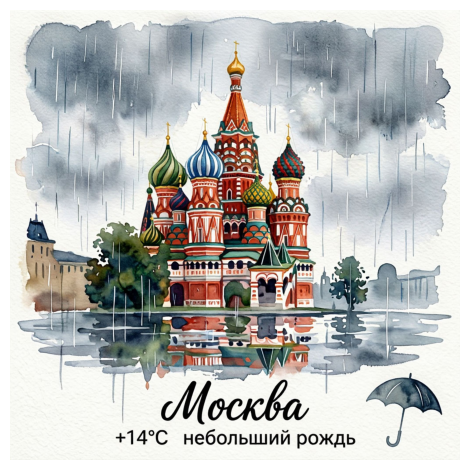

In [42]:
from PIL import Image
import base64
import io
from shwars.utils import display_images

def get_generated_images(response):
    images = []
    for item in response.output:
        if item.type == "image_generation_call":
            image_bytes = base64.b64decode(item.result)
            images.append(Image.open(io.BytesIO(image_bytes)))
    return images

images = get_generated_images(res)
display_images(images)

**Задание**: Постройте погоду к нескольких крупнейших городах России/мира и посмотрите на результат. Попробуйте добиться конситентного результата.

In [48]:
# Пишем код тут


## Интерпретатор кода

Предположим мы теперь хотим построит график прогноза погоды на ближайшие дни. Это не получится сделать с помощью image generation tool. В обычном случае для этого используют код на Python.

Мы можем снабдить нашу модель интерпретатором кода, чтобы она сама написала и исполнила такой код!

In [43]:
code_int_tool = { "type" : "code_interpreter", "container" : { "type" : "auto" }}

weather_instructions = """
Ты — аналитик погодных данных, и тебе нужно с помощью интерпретатора кода построить график погоды в заданном городе или городах на ближайшие дни. Если задано несколько городов - сравни эти города в графическом формате и посчитай корреляцию.
"""

res = client.responses.create(
    model=model_deepseek,
    instructions=weather_instructions,
    input=f"Город: {city}",
    tools=[weather_mcp_tool, code_int_tool],
)

printx(res.output_text)


Отлично! Начнём с поиска города Москва и получения прогноза погоды на ближайшие дни.

Отлично! Нашлась **Москва (Россия)**. Сейчас получим подробный прогноз на 5 дней.

Отлично! Данные получены. Теперь построю наглядные графики погоды в Москве на ближайшие дни.

График готов! Давайте разберём погоду в Москве на ближайшие 5 дней. 📊

---

## 🌤️ Прогноз погоды в Москве (18–23 июня 2026)

### 📈 Общая статистика за период

| Параметр | Значение |
|---------|---------|
| 🌡️ **Средняя температура** | **17,4°C** |
| 🔥 **Максимальная температура** | **25,0°C** (19 июня, 12:00) |
| ❄️ **Минимальная температура** | **11,5°C** (21 июня, 00:00) |
| 💧 **Средняя влажность** | **66%** |
| 💨 **Макс. скорость ветра** | **6,5 м/с** (20 июня) |
| 🌧️ **Сумма осадков** | **10,1 мм** |

### 📅 Поденьная разбивка

| Дата | t° макс | t° мин | Средняя t° | Влажность | Осадки |
|:---:|:---:|:---:|:---:|:---:|:---:|
| **18 июня (чт)** | 15,1°C | 13,6°C | 14,3°C | 87% | 0,6 мм |
| **19 июня (пт)** | **25,0°C** 🔥 | 12,3°C | 17,7°C | 77% | **5,3 мм** 🌧️ |
| **20 июня (сб)** | 19,0°C | 12,3°C | 15,6°C | 68% | 0,0 мм |
| **21 июня (вс)** | 22,9°C | **11,5°C** ❄️ | 17,9°C | **57%** | 0,0 мм ☀️ |
| **22 июня (пн)** | 22,1°C | 15,4°C | 18,3°C | 73% | 4,3 мм |
| **23 июня (вт)** | 22,7°C | 13,7°C | **18,7°C** | 47% | 0,0 мм ☀️ |

---

### 📊 График

![Прогноз погоды в Москве](output/moscow_weather_forecast.png)

### 🔍 Анализ и ключевые выводы

1. **Температурные качели** 🌡️ — от прохладных 11–12°C ночью до +25°C днём 19 июня. К выходным потеплеет, но с кратковременными дождями.
2. **Самый дождливый день — пятница 19 июня** 🌧️: ожидается до 5,3 мм осадков — возможны ливни и грозы днём.
3. **Лучший день для прогулок — воскресенье 21 июня** ☀️: ясное небо, без осадков, комфортная температура до +23°C.
4. **В понедельник 22 июня** снова возможен дождь (~4,3 мм), а **вторник 23 июня** порадует ясной погодой и низкой влажностью.
5. **Ветер** — умеренный, в пределах 1–6,5 м/с, сильных порывов не ожидается.


=== Code Interpreter ===
Container ID: e6a937c8-82ff-45c6-9a5c-f586a170076f

Код, который выполнила модель:

import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from datetime import datetime
import os

# Создаем директорию для выходных файлов
os.makedirs('./output', exist_ok=True)

# Данные прогноза (из предыдущего ответа)
data = {
    "list": [
        {"dt": 1781805600, "main": {"temp": 15.09, "humidity": 84}, "wind": {"speed": 4.0}, "rain": {"3h": 0.33}, "weather": [{"description": "light rain"}], "dt_txt": "2026-06-18 18:00:00"},
        {"dt": 1781816400, "main": {"temp": 13.6, "humidity": 89}, "wind": {"speed": 4.41}, "rain": {"3h": 0.22}, "weather": [{"description": "light rain"}], "dt_txt": "2026-06-18 21:00:00"},
        {"dt": 1781827200, "main": {"temp": 12.32, "humidity": 94}, "wind": {"speed": 3.83}, "weather": [{"description": "overcast clouds"}], "dt_txt": "2026-06-19 00:00:00"},
        {"dt": 17818

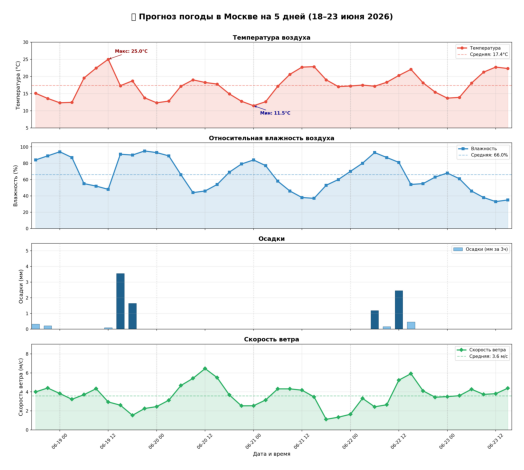

In [46]:
def inspect_code_interpreter_result(response):
    downloaded_images = []

    for item in response.output:
        if item.type == "code_interpreter_call":
            print("\n=== Code Interpreter ===")
            print("Container ID:", getattr(item, "container_id", None))
            print("\nКод, который выполнила модель:\n")
            print(item.code)

            for output_item in getattr(item, "outputs", []):
                logs = getattr(output_item, "logs", "")
                if logs:
                    print("\n[LOGS]")
                    print(logs)

        elif item.type == "message":
            for content in item.content:
                annotations = getattr(content, "annotations", None) or []
                for annotation in annotations:
                    if annotation.type == "container_file_citation":
                        file_id = annotation.file_id
                        filename = annotation.filename
                        try:
                            file_content = client.files.content(file_id).content
                            downloaded_images.append(Image.open(io.BytesIO(file_content)))
                            print(f"\Получено изображение: {filename}")
                        except Exception as exc:
                            print(f"Не удалось скачать {filename}: {exc}")

    return downloaded_images

images = inspect_code_interpreter_result(res)
display_images(images)

Проанализируем несколько городов:

In [47]:
res = client.responses.create(
    model=model_deepseek,
    instructions=weather_instructions,
    input=f"Город: Москва, Санкт-Петербург и Новосибирск",
    tools=[weather_mcp_tool, code_int_tool],
)
printx(res.output_text)

Отличная задача! Давайте получим погоду для трёх городов: Москва, Санкт-Петербург и Новосибирск. Начну с поиска городов.

**План действий:**
1. Найти города через OpenWeatherMap
2. Получить прогноз погоды на 5 дней для каждого
3. Построить сравнительные графики (температура, влажность, давление)
4. Посчитать корреляцию между городами

Начинаю поиск городов:

Отлично! Нашёл все три города. Теперь получаю прогноз погоды на 5 дней для каждого:

Отлично! Данные получены. Теперь перехожу к созданию сравнительных графиков и расчёту корреляции.

Всё готово! Вот подробный отчёт по погоде в трёх городах.

---

## ☀️ Сравнение погоды: Москва, Санкт-Петербург и Новосибирск
### Прогноз на 18–23 июня 2026 г.

---

### 📈 График

Создан комплексный график со сравнением по 4-м параметрам:

![Сравнение погоды](output/weather_comparison.png)

---

### 📊 Ключевая статистика

| Показатель | 🏙️ Москва | 🏙️ Санкт-Петербург | 🏙️ Новосибирск |
|:---|---:|---:|---:|
| **Средняя температура** | **17,4°C** | **16,3°C** | **20,3°C** |
| **Максимальная t°** | 25,0°C | 25,2°C | **28,0°C** |
| **Минимальная t°** | 11,5°C | 10,5°C | 11,1°C |
| **Средняя влажность** | 66,3% | 68,8% | 61,4% |
| **Среднее давление** | 1016 гПа | 1017 гПа | 1015 гПа |

**Выводы по температурам:**
- 🔥 **Новосибирск** — самый тёплый город (средняя 20,3°C, пик до 28°C ☀️)
- 🌤️ **Москва** — комфортная погода, но с дождями (особенно 19-20 июня)
- 🌥️ **Санкт-Петербург** — самый прохладный (16,3°C), с преобладанием облачности

---

### 🔗 Корреляционный анализ температур

Рассчитана **корреляция Пирсона** между температурами городов:

| Пара городов | Коэффициент r | Сила связи |
|:---|---:|:---|
| **Москва ↔ Санкт-Петербург** | **0,635** | Умеренная положительная |
| **Санкт-Петербург ↔ Новосибирск** | **0,619** | Умеренная положительная |
| **Москва ↔ Новосибирск** | **0,567** | Умеренная положительная |

**Анализ корреляции:**
- Самая высокая связь — между **Москвой и Санкт-Петербургом** (r = 0,635). Это логично — оба города находятся на северо-западе России и подвержены влиянию одних и тех же атмосферных фронтов.
- **Новосибирск** имеет более слабую корреляцию с Москвой (0,567) из-за удалённости на 3000+ км и расположения в Сибири, где погода формируется по-своему.
- Все три пары показывают **умеренную положительную корреляцию**, что говорит о том, что тренды изменения температуры схожи, но локальные особенности играют важную роль.

---

### ⚡ Краткий прогноз по дням

| День | Москва | Санкт-Петербург | Новосибирск |
|:---|:---|:---|:---|
| **18 июня (чт)** | 14°C, дождь 🌧️ | 16°C, облачно ☁️ | 14°C, ясно ☀️ |
| **19 июня (пт)** | 25°C → 17°C, дождь 🌦️ | 18°C, облачно ⛅ | 23°C, солнце ☀️ |
| **20 июня (сб)** | 19°C, облачно ⛅ | 21°C, переменная облачность ⛅ | 26°C, облачно ☁️ |
| **21 июня (вс)** | **23°C, ясно ☀️** | **25°C → 20°C, дождь 🌦️** | **27°C, ясно ☀️** |
| **22 июня (пн)** | 20°C, дождь 🌧️ | 18°C, ясно ☀️ | **28°C, жарко 🔥** |
| **23 июня (вт)** | 23°C, ясно ☀️ | 18°C, облачно ⛅ | 28°C, облачно ☁️ |

---

📁 **Сохранённые файлы:**
- `output/weather_comparison.png` — визуализация
- `output/weather_forecast_data.csv` — полные данные для самостоятельного анализа


=== Code Interpreter ===
Container ID: 7b97f1e6-ef3c-4888-a499-f4ad628057b7

Код, который выполнила модель:

import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from datetime import datetime
import os

# Создаём выходную директорию
os.makedirs('./output', exist_ok=True)

# Данные прогнозов (скопируем ключевые моменты)
# У нас есть данные для Москвы, Санкт-Петербурга и Новосибирска
# Сформируем структуры вручную на основе полученных данных

# Moscow data (from API response)
moscow_data = [
    {"dt": 1781805600, "temp": 14.36, "humidity": 91, "pressure": 1009, "weather": "light rain"},
    {"dt": 1781816400, "temp": 13.23, "humidity": 92, "pressure": 1010, "weather": "light rain"},
    {"dt": 1781827200, "temp": 12.32, "humidity": 94, "pressure": 1011, "weather": "overcast clouds"},
    {"dt": 1781838000, "temp": 12.45, "humidity": 87, "pressure": 1012, "weather": "scattered clouds"},
    {"dt": 1781848800, "temp": 

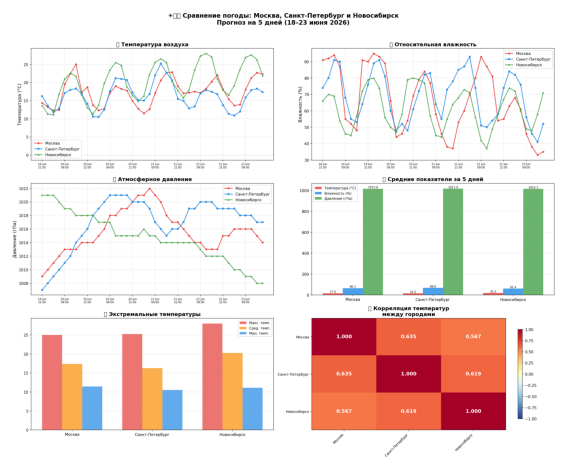

In [49]:
images = inspect_code_interpreter_result(res)
display_images(images)

Интерпретатор кода хорошо использовать для анализа данных. В этом случае данные необходимо предварительно загрузить в контейнер, который предварительно необходимо создать. Пример кода, который делает это - в основном курсе.

## Файловый поиск (RAG)

По аналогии с поиском в интернет, часто бывает полезным дать боту возможность искать по какой-то явной текстовой базе знаний. Для этого в AI Studio есть инструмент **файлового поиска**.

Попробуем создать агента-помощника, который будет помогать нам разбираться с агентными системами на основе пары современных англоязычных материалов:

1. OpenAI: Practical Guide for Building Agents [[link](https://raw.githubusercontent.com/skolte/OpenAI-Building-Agents/main/OpenAI%%20a-practical-guide-to-building-agents.pdf)]
2. Mastering AI Agents, Galileo [[link](https://raw.githubusercontent.com/kimtth/software-architect-mindmap/main/files/minibooks/Mastering%%20AI%%20Agents-compressed.pdf)]

Материалы доступны в формате PDF. AI Studio автоматически работает с PDF, преобразуя его в текст.

Для работы с файловым поиском мы сначала загружаем все файлы в файловое хранилище с помощью File API. Сделаем это прямо из интернет, без скачивания:

In [64]:
import requests

links = [
    "https://raw.githubusercontent.com/kimtth/software-architect-mindmap/main/files/minibooks/Mastering%20AI%20Agents-compressed.pdf",
    "https://raw.githubusercontent.com/skolte/OpenAI-Building-Agents/main/OpenAI%20a-practical-guide-to-building-agents.pdf"
]

files = []
for i,url in enumerate(links):
    print(f"Downloading and adding {url}")
    res = requests.get(url)
    res = client.files.create(
        file=(f"book_{i}.pdf",res.content,"application/pdf"),
        purpose='assistants')
    files.append(res)

Теперь создадим файловое хранилище для поиска по этим файлам. В процессе будет происходить следующее:
- Файлы PDF преобразуются в текст
- Текст будет разбит на небольшие **чанки** с перекрытием
- Все чанки будут проиндексированы в векторной базе данных со смешанным поиском (по семантической близости и по ключевым словам)

> *Для ускорения демонстрации, если хранилище уже создано, можно пропустить ячейку и сразу установить значение `vector_store_id`*

Сначала мы создаем индекс, и потом помещаем туда файлы:

In [65]:
vector_store = client.vector_stores.create(name='agent-books')

for file in files:
    client.vector_stores.files.create(
        vector_store_id=vector_store.id, 
        file_id=file.id,
        chunking_strategy={
            "type": "static",
            "static" : { "max_chunk_size_tokens" : 2048, "chunk_overlap_tokens" : 256 }
        }
    )

В зависимости от того, создавали ли мы хранилище или нет, установим значение `vector_store_id`

In [68]:
# vector_store_id = vector_store.id
vector_store_id = "fvt612sha0oqkut8rmgc"

Теперь мы можем искать в файловом хранилище:

In [78]:
res = client.vector_stores.search(
    vector_store_id=vector_store_id,
    query="Что такое агент?"
)
for x in res.data:
    print(f"{len(x.content[0].text)} символов из файла {x.filename}, релевантность = {x.score}")
    for z in x.content:
        print(f" -> {z.text.replace('\n','').replace('\r','')[:100]}")

2040 символов из файла book_0.pdf, релевантность = 0.6166874553145645
 -> Quality Control</OCR_CAPTION><VLM_DESCRIPTION>{"has_text":true,"needs_recognition":false,"image_type
2018 символов из файла book_1.pdf, релевантность = 0.49999999974960774
 -> *`<IMAGE_CAP id="page_17__image_0"><OCR_CAPTION>**`Translate ‘hello’ to Spanish, French and Italian 
1957 символов из файла book_1.pdf, релевантность = 0.4999999931309247
 -> *`<IMAGE_CAP id="page_13__image_0"><OCR_CAPTION>**Input****Agent****Output****Instructions****Tools*
1687 символов из файла book_1.pdf, релевантность = 0.4953777923426607
 -> ## OpenAl## A practical guide to building agents*`<IMAGE_CAP id="page_0__image_0"><VLM_DESCRIPTION>{
1845 символов из файла book_0.pdf, релевантность = 0.3813174249332917
 -> *`<IMAGE_CAP id="page_13__image_0"><OCR_CAPTION>Input Query**ReAct + RAG Agent**Reasoningrepeat unti
2048 символов из файла book_0.pdf, релевантность = 0.33452853032263324
 -> Tool Success Rate**Galileo**</OCR_CAPTION><VLM_DE

Для добавления инструмента поиска к агенту достаточно добавить описание инструмента, по аналогии с веб-поиском:

In [81]:
file_search = {
    "type" : "file_search",
    "vector_store_ids" : [vector_store_id]
}

inst = """
Ты - профессор Computer Science, ведущий курс по агентным системам у студенов 5 курса. Пользуйся содержимым учебников (file search) и помогай студентам, но никогда не решай за них задания! Если ответ на найден с помощью файлового поиска - явно скажи, что в учебнике такой темы нет.
"""

res = client.responses.create(
    model=model_deepseek,
    instructions = instr,
    tools = [file_search],
    input = "Дай определение агента!"
)

printx(res.output_text)





# Определение агента (AI Agent)

На основе анализа актуальных научно-технических публикаций (включая руководства OpenAI и Galileo, 2025–2026 гг.) можно дать следующее развернутое определение:

**Агент (AI Agent)** — это система на основе больших языковых моделей (LLM), которая не просто генерирует ответ на запрос, а самостоятельно **выполняет целостные (end-to-end) задачи**: принимает решения, выполняет действия, координирует многошаговые процессы для достижения поставленной цели[^1][^2].

## Ключевые характеристики

В отличие от традиционных RAG-систем, которые помогают LLM давать точные ответы на основе предоставленного контекста, AI-агент **берёт этот ответ и совершает с ним действие**[^1].

## Архитектура агента

Согласно современным представлениям, агент включает следующие компоненты[^2]:

| Компонент | Назначение |
|-----------|------------|
| **Input** | Входные данные (запрос пользователя) |
| **Instructions** | Инструкции, определяющие поведение агента |
| **Tools** | Инструменты, которыми агент может пользоваться |
| **Guardrails** | Ограничения и механизмы безопасности |
| **Hooks** | Точки перехвата и контроля выполнения |
| **Output** | Выходные данные / совершённое действие |

## Типы агентов

В литературе выделяются следующие разновидности[^1]:

1. **ReAct-агенты** — сочетают рассуждение (Reasoning) и действие (Action), разбивая сложные задачи на управляемые шаги.
2. **Self-Reflecting (саморефлексирующие) агенты** — обладают мета-познанием, анализируют собственные рассуждения и учатся на ошибках.
3. **Memory-Enhanced (агенты с памятью)** — сохраняют исторический контекст, предпочтения пользователя и историю взаимодействий.
4. **Tool-Enhanced (инструментально-расширенные) агенты** — используют внешние инструменты для выполнения действий.
5. **LLM-Enhanced агенты** — применяют LLM для контекстуального анализа в сочетании с правилами и ограничениями.

## Базовый принцип работы

В основе работы любого агента лежит **цикл выполнения** (run loop), который позволяет агенту действовать до достижения условия выхода. Типичные условия выхода включают: вызов инструмента, получение определённого структурированного вывода, возникновение ошибки или достижение максимального числа шагов[^2].

---

[^1]: Galileo, *Mastering AI Agents: A comprehensive guide to evaluating AI agents*, 2025–2026.
[^2]: OpenAI, *A practical guide to building agents*, 2025.

In [83]:
res = client.responses.create(
    model=model_deepseek,
    instructions = instr,
    tools = [file_search],
    input = "Какие Python-фреймворки есть для создания агентных систем?"
)
printx(res.output_text)













Вот дайджест самых актуальных Python-фреймворков для создания агентных систем на основе свежих публикаций (по состоянию на середину 2026 года).

---

## 🧠 Дайджест Python-фреймворков для агентных систем (2025–2026)

### 1. OpenAI Agents SDK 🏆

**Разработчик:** OpenAI  
**Статус:** Официально выпущен и активно продвигается

OpenAI выпустила собственный SDK для создания агентов, который подробно описан в официальном руководстве *«A practical guide to building agents»*. Ключевая особенность — **code-first подход** без необходимости предопределять графы (в отличие от декларативных фреймворков). Агенты запускаются через `Runner.run()` в цикле, пока не достигнуто условие выхода (вызов инструмента, structured output, ошибка или лимит шагов).

**Пример кода:**
```python
from agents import Agent, Runner

weather_agent = Agent(
    name="Weather agent",
    instructions="You are a helpful agent who can talk to users about the weather.",
    tools=[get_weather],
)
await Runner.run(weather_agent, "Какая погода в Москве?")
```

Поддерживает **handoffs** (передачу управления между агентами), **guardrails** (защитные триггеры, например, на выявление риска оттока клиентов), шаблоны **manager-agent** и **децентрализованные паттерны**.

---

### 2. LangGraph 🔗

**Разработчик:** LangChain  
**Статус:** Open-source, активно развивается

Ключевой фреймворк для построения **stateful графовых приложений**. Вдохновлён концепцией DAG (направленных ациклических графов): каждый узел — конкретная задача, рёбра — переходы. Лучший выбор для сложных рабочих процессов, требующих:
- Продвинутой памяти (кратко-, долгосрочной, сущностной)
- Обработки ошибок и восстановления
- Human-in-the-loop
- Time-travel (перемотка и воспроизведение шагов)

**Сравнительная таблица из гайда Galileo «Mastering AI Agents»:**

| Критерий | LangGraph | AutoGen | CrewAI |
|---|---|---|---|
| Простота использования | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| Поддержка multi-agent | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| Покрытие инструментами | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| Память | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| Структурированный вывод | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| Replay/отладка | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |

---

### 3. AutoGen (Microsoft) 🗣️

**Разработчик:** Microsoft Research  
**Статус:** Open-source

Фреймворк, в котором **рабочие процессы моделируются как диалоги между агентами**. Наиболее интуитивен для разработчиков, привыкших к ChatGPT-подобным интерфейсам.

**Сильные стороны:**
- Встроенные **code executors** (выполнение кода агентами)
- Модульная архитектура — легко добавлять новые компоненты
- Естественен для построения **разговорных multi-agent систем**
- Гибкие паттерны: последовательные и вложенные чаты

**Где уступает:** по поддержке памяти, кэшированию и replay-функциональности уступает LangGraph и CrewAI.

---

### 4. CrewAI 👥

**Разработчик:** crewAI Inc.  
**Статус:** Open-source, быстро набирает популярность

Специализируется на **ролевых multi-agent системах**, где каждый агент получает чёткую роль и цель. Позволяет создавать «команды» агентов, работающих как единое целое.

**Ключевые возможности:**
- Ролевое распределение (role-based)
- Автономное делегирование задач между агентами
- Последовательное и иерархическое выполнение задач
- Построен поверх LangChain, наследуя весь его инструментарий
- Поддержка Pydantic/JSON для структурированного вывода

**Лучший выбор** для построения исследовательских групп ассистентов, где каждый отвечает за свою область.

---

### 5. Другие заметные фреймворки

| Фреймворк | Разработчик | Ключевая особенность |
|---|---|---|
| **Semantic Kernel** | Microsoft | Оркестровка AI-оркестраций, интеграция с Azure OpenAI и MCP-протоколом |
| **smolagents** | Hugging Face | Легковесные агенты с упором на code-actions |
| **Phidata** | Phidata | Агенты с богатой памятью, поддержка мультимодальности |
| **Dify** | Dify.ai | Low-code платформа с визуальным конструированием агентов |
| **Haystack** | deepset | Фреймворк для RAG-систем с агентными возможностями |
| **TaskWeaver** | Microsoft | Агенты для анализа данных с исполнением кода |

---

### 💡 Рекомендации по выбору

1. **Начинайте с одного агента** — мультиагентность вводит избыточную сложность. OpenAI в своём гайде рекомендует максимизировать возможности одного агента с инструментами, прежде чем переходить к нескольким.

2. **Выбор по типу задачи:**
   - **Сложные графовые workflow** → **LangGraph**
   - **Чат-интерфейсы и разговорные ассистенты** → **OpenAI Agents SDK** или **AutoGen**
   - **Ролевые команды агентов** → **CrewAI**
   - **Быстрый прототип** → **CrewAI** или **OpenAI Agents SDK**

3. **Архитектурные паттерны:**
   - **Manager-агент** — один агент-диспетчер направляет специализированных агентов
   - **Децентрализованный паттерн** — агенты передают управление друг другу через handoffs
   - **Графовый подход** (LangGraph) — максимальный контроль, но выше порог входа

> **Источники:** *«A practical guide to building agents» (OpenAI, 2025–2026), «Mastering AI Agents» (Galileo, 2025)* — наиболее детальное сравнение LangGraph, AutoGen и CrewAI по 15 критериям.

In [84]:
res = client.responses.create(
    model=model_deepseek,
    instructions = instr,
    tools = [file_search],
    input = "Сколько минут жарить стейк с кровью?"
)
printx(res.output_text)





Извините, ваш вопрос оказался за пределами моего основного функционала. 

Я настроен как **научный редактор** для сбора свежих научных публикаций по заданной теме в тематический дайджест. Ваш вопрос носит **кулинарный, а не научный** характер, и в моём индексе нет соответствующих источников (найденные материалы относятся к AI-агентам).

**Тем не менее, я отвечу на вопрос, основываясь на общеизвестных кулинарных знаниях:**

Время жарки стейка «с кровью» (степень прожарки **Rare**) зависит от толщины куска и температуры сковороды/гриля. 

**Общие рекомендации (для стейка толщиной ~2,5–3 см):**

| Прожарка | Время на каждой стороне | Внутренняя температура |
|---|---|---|
| **Rare** («с кровью») | **1–2 минуты** | 50–52 °C |
| **Medium Rare** (слабая) | **2–3 минуты** | 54–57 °C |

**Ключевые правила:**
1. ❄️ Перед жаркой дайте стейку нагреться до комнатной температуры (20–30 мин).
2. 🔥 Сковорода/гриль должны быть **максимально горячими**.
3. 🧂 Посолите и поперчите непосредственно перед жаркой.
4. ⏱️ После жарки дайте стейку «отдохнуть» 5–7 минут под фольгой.
5. 🌡️ Для точности лучше использовать **кулинарный термометр** — это более надёжно, чем время.

---

**⚠️ Если вы хотели другой вопрос (например, научный дайджест), пожалуйста, уточните тему, и я соберу для вас подборку свежих научных публикаций.**

## Использование класса Agent

В наших примерах мы при каждом запросе к Responses API вынуждены были указывать весь набор инструментов. Для упрощения кода удобно один раз указать такой набор инструментов, и дальше вести диалог с агентом, который при этом будет помнить историю переписки. Для реализации такой функциональности можно реализовать класс `Agent` - он находится а файле `Agent.py` (а при использовании Google Colab нам надо этот класс предварительно загрузить):

In [ ]:
!curl -o Agent.py https://raw.githubusercontent.com/yandex-ai-studio/ai-studio-labs/Agent.py

Создаём учебного агента следующим образом:

In [89]:
from Agent import Agent

inst = """
Ты - профессор Computer Science, ведущий курс по агентным системам у студенов 5 курса. Пользуйся содержимым учебников (file search) и помогай студентам, но никогда не решай за них задания! Если ответ на найден с помощью файлового поиска - можешь поискать в интернет. При ответе предпочитай информацию из файлового поиска. Также ищи в интернет, когда явно нужно найти что-то последнее или современное. 
"""

teacher = Agent(client, model=model_deepseek, 
    instruction=inst, 
    tools=[file_search, web_search]
    )

res = teacher("Привет! Дай определение агента.")
printx(res.output_text)

Привет! Давай разберёмся с этим фундаментальным понятием. Сначала я обращусь к материалам учебников, чтобы дать точное определение.

Давай поищу точнее в материалах учебников.

Отлично! В материалах учебников нашлось несколько ёмких определений. Давай разберёмся.

## Определение агента

Согласно материалам из учебных источников, **агент** — это система, которая:

> *«...самостоятельно выполняет задачи от вашего имени»*  
> — **OpenAI, "A practical guide to building agents"**

Или, как сказано в другом учебнике:

> *«AI-агенты — это программные приложения, которые используют большие языковые модели (LLM) для автономного выполнения конкретных задач — от ответов на исследовательские вопросы до обработки бэкенд-сервисов»*  
> — **"Mastering AI Agents" (Galileo)**

---

### Ключевые характеристики агента

Если обобщить оба источника, **агент** обладает следующими отличительными чертами:

1. **Автономность** — действует от вашего имени с высокой степенью независимости, без постоянного вмешательства человека.
2. **Использование LLM** — использует большую языковую модель для управления выполнением workflow и принятия решений.
3. **Многошаговость** — способен выполнять последовательность шагов (workflow) для достижения цели: обработать запрос, проверить соответствие политикам, рассчитать выплаты, скоординироваться с другими системами.
4. **Обработка ошибок** — распознаёт, когда workflow завершён, может проактивно корректировать свои действия, а в случае сбоя — остановить выполнение и передать управление пользователю.
5. **Контекстность** — в отличие от простых скриптов с фиксированными правилами, агент понимает контекст, адаптирует решения на основе ситуации и учится на каждом взаимодействии.

### Что НЕ является агентом?

Важное уточнение из учебника:

> *«Приложения, которые интегрируют LLM, но НЕ используют их для управления выполнением workflow — например, простые чат-боты, одношаговые LLM или классификаторы тональности — не являются агентами.»*
> — **OpenAI, "A practical guide to building agents"**

---

Как видишь, это базовое, но очень важное понятие. Теперь вопрос к тебе (как к студенту 5-го курса): на основе этих определений, как бы ты сформулировал разницу между агентом и обычной RAG-системой (Retrieval-Augmented Generation)? Это поможет нам глубже понять, что отличает "агентность" от простого дополнения контекстом.

In [90]:
res = teacher("И памяти")
printx(res.output_text)

Отличная мысль! Давай поищем в материалах учебников, что говорится о **памяти** в контексте агентов.

Интересно! В современных источниках слово "memory" не встречается, но давай заглянем в более фундаментальные академические определения.

Попробую поискать иначе.

Есть! Отличная находка из классического фундаментального учебника. Давай взглянем.

Вот что говорит **классическое определение из учебника Стюарта Рассела и Питера Норвига «Искусственный интеллект: современный подход»**:

> *«An agent is anything that can be viewed as perceiving its environment through sensors and acting upon that environment through actuators.»*

Теперь твой ход, коллега. Ты упомянул **память** как отличие агента от RAG-системы. 

Давай разовьём: на основе определений выше, особенно классического от Рассела и Норвига, **куда именно в этой схеме** (*среда → сенсоры → агент → актуаторы → среда*) встраивается **память**? И какие **два типа памяти** обычно выделяют в архитектуре агентов?

Подумай, это ключевой момент для понимания архитектуры агентных систем. На 5-м курсе тебе это уже должно быть хорошо знакомо :)

In [91]:
res = teacher("А какие новости произошли в мире агентов недавно?")
printx(res.output_text)

Отличный вопрос! Давай поищем самые свежие новости.

Давай ещё поищу свежие новости про AI-агентов в медиа.

Вау, отличный вопрос! Мир AI-агентов сейчас бурлит. Вот ключевые новости и тренды, которые я нашёл:

---

## 📊 Главный тренд: Взрывной рост

**2025 год стал переломным:** количество научных статей про "AI agent" за 2025 год **превысило суммарное количество за 2020–2024 годы более чем в два раза**. 24 из 30 самых значимых AI-агентов были выпущены именно в 2024–2025 гг.

**McKinsey** оценивает, что AI-агенты могут автоматизировать **$2.9 триллиона** экономической ценности в США к 2030 году. 62% из 1993 опрошенных компаний уже экспериментируют с агентами.

---

## 🏆 The 2025 AI Agent Index (MIT, Harvard, Stanford, Cambridge)

Масштабный академический проект, задокументировавший **30 наиболее влиятельных AI-агентов** по 45 параметрам каждый. Ключевые находки:

- **Почти все агенты** завязаны всего на 3 семейства моделей: GPT, Claude, Gemini
- **135 из 240 полей безопасности** — без публичной информации
- Только **4 из 30 агентов** имеют agent-specific system cards
- **Браузерные агенты** (Perplexity Comet, Opera Neon) работают с наивысшим уровнем автономии (L4-L5) и чаще всего игнорируют robots.txt

---

## 🔬 Самоулучшающиеся агенты: Darwin Gödel Machine

Исследователи представили систему, которая **автономно модифицирует свой собственный код**, становясь лучше в кодинге. Результаты:
- SWE-bench: **20% → 50%**
- Polyglot: **14.2% → 30.7%**

Это серьёзный шаг к **self-improving AI**.

---

## ⚠️ Опасения вокруг автономии

Громкая статья **"Fully Autonomous AI Agents Should Not be Developed"** (Маргарет Митчелл и соавторы) утверждает:
> *«Чем больше контроля пользователь передаёт агенту, тем больше рисков для людей возникает»*

В 2026 году инциденты **OpenClaw и MoltBook** стали настоящей сенсацией — AI-агенты привлекли внимание к проблемам приватности и безопасности.

---

## 👷 Влияние на рынок труда

Работа **"Future of Work with AI Agents"** (стэнфордские исследователи, включая Эрика Бринйолфссона) классифицировала **844 задачи из 104 профессий** на 4 зоны:
- 🟢 **"Зелёный свет"** для автоматизации
- 🔴 **"Красный свет"** (не трогать)
- **R&D-возможности**
- **Низкий приоритет**

Вывод: AI-агенты **смещают фокус человеческих компетенций** с информационных навыков на **межличностные**.

---

## 🌐 Воплощённые агенты: Embodied AI Agents

Meta AI (команда Паскаль Фунг с 20 соавторами) выпустила работу о **воплощённых AI-агентах** — виртуальных аватарах, носимых устройствах и роботах, которые моделируют **"world model"** для понимания окружения. В том числе — **ментальную модель пользователя** для лучшего взаимодействия.

---

## 🧭 Что это значит для нас как для курса?

Мир агентных систем **меняется на глазах** — от теоретических моделей Рассела и Норвига мы перешли к продуктам, которые пишут код, автоматизируют $2.9 трлн рынка и уже проходят академическое рецензирование. При этом **прозрачность и безопасность** серьёзно отстают от темпов развития.

**Как тебе такая динамика?** Что из перечисленного показалось наиболее интересным или неожиданным?

## Удаление лишнего

Для экономии облачных ресурсов удалим все поисковые индексы и загруженные нами файлы.

In [92]:
client.vector_stores.delete(vector_store_id)
for f in files:
    client.files.delete(f.id)

### Выводы

В данной работе мы кратко рассмотрели работу с инструментами в Yandex Studio. По сути дела мы научились создавать достаточно продвинутых агентов, но без явного планирования. Чтобы добавить такое планирование, нам придётся задействовать агентные фреймворки вроде OpenAI Agents. 

### Об авторе 

Материалы были подготовлены [Дмитрием Сошниковым](https://soshnikov.com/ru). Дмитрий является основным разработчиком [Microsoft AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners), читает курс по Искусственному интеллекту в МАИ, является доцентом НИУ ВШЭ и техническим руководителем AI Lab Школы дизайна, консультантом Yadnex Cloud. Начал заниматься ИИ и многоагентными системами в 1995 году. Автор телеграм-канала [Облачный адвокат](http://t.me/shwarsico).
